# Prediction of Heart Disease
## Import Libraries and Configuration

In [1]:
# =============================================================================
# Imports & Configuration
# =============================================================================
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold, StratifiedKFold, ShuffleSplit, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, RobustScaler, OrdinalEncoder, LabelEncoder, KBinsDiscretizer
from sklearn.metrics import roc_auc_score, roc_curve, auc

from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

# =============================================================================
# Config
# =============================================================================
CONFIG = {
    "ADD_EXTERN_DATA": False,
    "USE_STRATIFIED_SPLIT": False,
    "USE_EXTENDED_STRAT": False,
    "VAL_SIZE": 0.001,
    "N_FOLDS": 5,
    "SEEDS": [42, 123, 456],
    "GPU_ACC": True,
    "TARGET": "Heart Disease",
}

NUM_COLS = ["Age", "BP", "Cholesterol", "Max HR", "ST depression"]
CAT_COLS = [
    "Sex", "Chest pain type", "FBS over 120", "EKG results",
    "Exercise angina", "Slope of ST", "Number of vessels fluro", "Thallium"
]

print("Completed Loading Libraries and Configuration ...")


Completed Loading Libraries and Configuration ...


## Load Data and Generate Summaries

In [2]:
# =============================================================================
# Data Loading
# =============================================================================
train_df = pd.read_csv("/kaggle/input/playground-series-s6e2/train.csv")
test_df = pd.read_csv("/kaggle/input/playground-series-s6e2/test.csv")

if CONFIG["ADD_EXTERN_DATA"]:
    original_df = pd.read_csv("/kaggle/input/heart-disease-original/Heart_Disease_Prediction.csv")
    train_df = pd.concat(
        [train_df.iloc[:, 1:], original_df[train_df.columns[1:]]],
        ignore_index=True
    ).reset_index().rename(columns={"index": "id"})

trainval = train_df.copy()
test = test_df.copy()

# Encode target
le = LabelEncoder()
trainval[CONFIG["TARGET"]] = le.fit_transform(trainval[CONFIG["TARGET"]]).astype(np.uint8)

print("Completed Loading Data ...")

Completed Loading Data ...


In [3]:
def create_summary(df):
    describe = df.describe().transpose()
    summary = pd.DataFrame(df.dtypes, columns=['DataType'])
    summary['MissingValues'] = df.isnull().sum()
    summary['UniqueValues'] = df.nunique()
    summary['FirstValue'] = df.iloc[0]
    summary['SecondValue'] = df.iloc[1]
    summary['ThirdValue'] = df.iloc[2]
    summary = pd.concat([summary, describe], axis=1)
    summary = summary.fillna('--')
    return summary

print("Summary Descfription of Training Dataset ...")
create_summary(train_df)

Summary Descfription of Training Dataset ...


,DataType,MissingValues,UniqueValues,FirstValue,SecondValue,ThirdValue,count,mean,std,min,25%,50%,75%,max
id,int64,0,630000,0,1,2,630000.0,314999.5,181865.479132,0.0,157499.75,314999.5,472499.25,629999.0
Age,int64,0,42,58,52,56,630000.0,54.136706,8.256301,29.0,48.0,54.0,60.0,77.0
Sex,int64,0,2,1,1,0,630000.0,0.714735,0.451541,0.0,0.0,1.0,1.0,1.0
Chest pain type,int64,0,4,4,1,2,630000.0,3.312752,0.851615,1.0,3.0,4.0,4.0,4.0
BP,int64,0,66,152,125,160,630000.0,130.497433,14.975802,94.0,120.0,130.0,140.0,200.0
Cholesterol,int64,0,150,239,325,188,630000.0,245.011814,33.681581,126.0,223.0,243.0,269.0,564.0
FBS over 120,int64,0,2,0,0,0,630000.0,0.079987,0.271274,0.0,0.0,0.0,0.0,1.0
EKG results,int64,0,3,0,2,2,630000.0,0.98166,0.998783,0.0,0.0,0.0,2.0,2.0
Max HR,int64,0,93,158,171,151,630000.0,152.816763,19.112927,71.0,142.0,157.0,166.0,202.0
Exercise angina,int64,0,2,1,0,0,630000.0,0.273725,0.44587,0.0,0.0,0.0,1.0,1.0


## Define Feature Engineering

In [4]:
def add_engineered_features(df):
    df = df.copy()

    # ---------------------------
    # Ratio features
    # ---------------------------
    df["chol_age_ratio"] = df["Cholesterol"] / (df["Age"] + 1)
    df["bp_age_ratio"]   = df["BP"] / (df["Age"] + 1)
    df["hr_age_ratio"]   = df["Max HR"] / (df["Age"] + 1)
    df["st_hr_ratio"]    = df["ST depression"] / (df["Max HR"] + 1)

    # ---------------------------
    # Non-linear transforms
    # ---------------------------
    df["age_sq"] = df["Age"] ** 2
    df["st_sq"]  = df["ST depression"] ** 2
    df["log_age"] = np.log1p(df["Age"])
    df["sqrt_chol"] = np.sqrt(df["Cholesterol"].clip(lower=0))

    # ---------------------------
    # Binary clinical flags
    # ---------------------------
    df["is_senior"]   = (df["Age"] >= 55).astype(np.uint8)
    df["high_chol"]   = (df["Cholesterol"] >= 240).astype(np.uint8)
    df["high_bp"]     = (df["BP"] >= 140).astype(np.uint8)
    df["low_hr"]      = (df["Max HR"] < 120).astype(np.uint8)
    df["st_present"]  = (df["ST depression"] > 0).astype(np.uint8)

    # ---------------------------
    # Categorical interactions
    # ---------------------------
    df["sex_chestpain"] = df["Sex"].astype(str) + "_" + df["Chest pain type"].astype(str)
    df["thal_vessels"]  = df["Thallium"].astype(str) + "_" + df["Number of vessels fluro"].astype(str)
    df["exercise_slope"] = df["Exercise angina"].astype(str) + "_" + df["Slope of ST"].astype(str)

    return df

train_df = add_engineered_features(train_df)
test_df  = add_engineered_features(test_df)

NUM_COLS_EXT = NUM_COLS + [
    "chol_age_ratio", "bp_age_ratio", "hr_age_ratio", "st_hr_ratio",
    "age_sq", "st_sq", "log_age", "sqrt_chol"
]

BIN_COLS = [
    "is_senior", "high_chol", "high_bp",
    "low_hr", "st_present"
]

CAT_COLS_EXT = CAT_COLS + [
    "sex_chestpain", "thal_vessels", "exercise_slope"
]

print("Completed generating Feature Engineering ...")

Completed generating Feature Engineering ...


## Training and Validating 

In [5]:
# =============================================================================
# Train / Validation Split
# =============================================================================
strat_col = (
    trainval[CONFIG["TARGET"]]
    if not CONFIG["USE_EXTENDED_STRAT"]
    else trainval[["Thallium", "Chest pain type"]].astype(str).agg("_".join, axis=1)
)

splitter_class = StratifiedShuffleSplit if CONFIG["USE_STRATIFIED_SPLIT"] else ShuffleSplit
splitter = splitter_class(n_splits=1, test_size=CONFIG["VAL_SIZE"], random_state=42)

train_idx, val_idx = next(splitter.split(trainval, strat_col))

train = trainval.iloc[train_idx].copy().reset_index(drop=True)
val = trainval.iloc[val_idx].copy().reset_index(drop=True)

y_train = train[CONFIG["TARGET"]] 
y_val = val[CONFIG["TARGET"]]

# =============================================================================
# Target Encoding Stats (Leakage Safe)
# =============================================================================
GLOBAL_MEAN = y_train.mean()

# FIX 2: Group by the feature in 'train' but aggregate the values from 'y_train'
stats_mean = {c: y_train.groupby(train[c]).mean().to_dict() for c in NUM_COLS + CAT_COLS}

def freq_enc(X):
    # Ensure X is a DataFrame for pandas operations
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    return X.apply(lambda c: c.map(c.value_counts(normalize=True)).fillna(0))

def target_enc(X, stats, default):
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    # Ensure we use the correct column names from the stats dictionary
    return X.apply(lambda c: c.map(stats.get(c.name, {})).fillna(default))

# =============================================================================
# Preprocessing
# =============================================================================
train_features = train.drop(columns=[CONFIG["TARGET"]])
val_features = val.drop(columns=[CONFIG["TARGET"]])
test_features = test.drop(columns=[CONFIG["TARGET"]], errors='ignore')

preprocessing = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", RobustScaler())
    ]), NUM_COLS),

    ("kbins", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("kb", KBinsDiscretizer(n_bins=10, encode="ordinal")),
    ]), NUM_COLS),

    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ]), CAT_COLS),

    ("freq", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        # Use check_inverse=False to avoid errors with FunctionTransformer
        ("frq", FunctionTransformer(freq_enc, check_inverse=False))
    ]), CAT_COLS),

    ("mean", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("mean_enc", FunctionTransformer(lambda x: target_enc(x, stats_mean, GLOBAL_MEAN), check_inverse=False))
    ]), NUM_COLS + CAT_COLS),
], remainder="drop")

preprocessing.set_output(transform="pandas")

X_train = preprocessing.fit_transform(train_features)
X_val = preprocessing.transform(val_features)
X_test = preprocessing.transform(test_features)

print("Preprocessing Completed Successfully.")


Preprocessing Completed Successfully.


## Model Training

In [6]:
# =============================================================================
# Model Training
# =============================================================================
models = {}
start = time.time()

y_train_series = pd.Series(y_train) if not isinstance(y_train, pd.Series) else y_train
y_val_series = pd.Series(y_val) if not isinstance(y_val, pd.Series) else y_val

for seed in CONFIG["SEEDS"]:
    cv = KFold(n_splits=CONFIG["N_FOLDS"], shuffle=True, random_state=seed)
    
    for fold, (tr, ev) in enumerate(cv.split(X_train), 1):
        model = CatBoostClassifier(
            n_estimators=5000,
            learning_rate=0.03,
            depth=6,
            eval_metric="AUC",
            auto_class_weights="Balanced",
            random_seed=seed,
            early_stopping_rounds=100,
            verbose=False,
        )

        model.fit(
            X_train.iloc[tr], y_train_series.iloc[tr],
            eval_set=(X_train.iloc[ev], y_train_series.iloc[ev]),
            use_best_model=True # Important to use the best iteration from early stopping
        )

        models[f"s{seed}_f{fold}"] = model
        print(f"Finished Seed {seed} | Fold {fold}", end='\r')

print(f"\nTrained {len(models)} models in {int(time.time()-start)}s")

# =============================================================================
# Evaluation
# =============================================================================
val_preds_list = [m.predict_proba(X_val)[:, 1] for m in models.values()]
train_preds_list = [m.predict_proba(X_train)[:, 1] for m in models.values()]

val_preds = np.mean(val_preds_list, axis=0)
train_preds = np.mean(train_preds_list, axis=0)

# Final Scoring
train_auc = roc_auc_score(y_train_series, train_preds)
val_auc = roc_auc_score(y_val_series, val_preds)

print("-" * 30)
print(f"Ensemble AUC")
print(f"Train: {train_auc:.6f}")
print(f"Val:   {val_auc:.6f}")
print("-" * 30)


Finished Seed 456 | Fold 5
Trained 15 models in 1083s
------------------------------
Ensemble AUC
Train: 0.956482
Val:   0.948326
------------------------------


## Generate ROC Curve

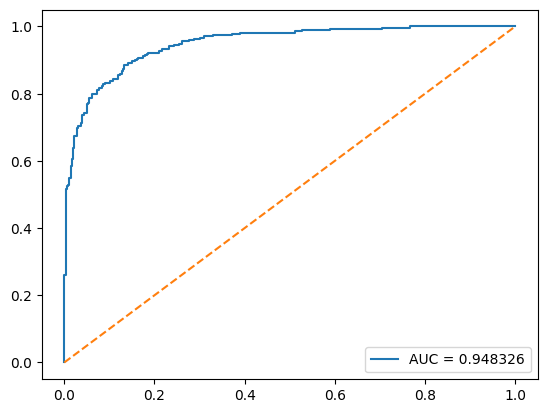

In [7]:
# =============================================================================
# ROC Curve
# =============================================================================
fpr, tpr, _ = roc_curve(y_val, val_preds)
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.6f}")
plt.plot([0, 1], [0, 1], "--")
plt.legend()
plt.show()



## Submission

In [8]:
# =============================================================================
# Submission
# =============================================================================
test_preds = np.mean([m.predict_proba(X_test)[:, 1] for m in models.values()], axis=0)

submission = test[["id"]].copy()
submission[CONFIG["TARGET"]] = test_preds
submission.to_csv("submission.csv", index=False)

print("✅ submission.csv saved")

submission.head(10)

✅ submission.csv saved


,id,Heart Disease
0,630000,0.959463
1,630001,0.008463
2,630002,0.992994
3,630003,0.004697
4,630004,0.234612
5,630005,0.987458
6,630006,0.005274
7,630007,0.619483
8,630008,0.993908
9,630009,0.014578
